In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh

np.random.seed(42)
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['font.size'] = 12

In [2]:
N = 3000  # размер матрицы
n_bins = 50
n_samples = 1  # количество матриц для усреднения

def semicircle(x):
    """Полукруговой закон Вигнера"""
    r = 2
    return np.where(np.abs(x) <= r, np.sqrt(4 - x**2) / (np.pi * r), 0)

In [3]:
def get_eigenvalues(distribution, size=N, samples=n_samples):
    """Возвращает собственные числа случайных симметрических матриц"""
    eigenvalues = []
    
    for _ in range(samples):
        if distribution == 'normal':
            # Нормальное распределение
            A = np.random.randn(size, size)
            
        elif distribution == 'uniform':
            # Равномерное распределение на [-1, 1]
            A = (2 * np.random.rand(size, size) - 1) * np.sqrt(3)
            
        elif distribution == 'bernoulli':
            # Бернулли: +1 или -1
            A = 2 * np.random.randint(0, 2, (size, size)) - 1
            
        elif distribution == 'exponential':
            # Экспоненциальное (с центрированием)
            A = np.random.exponential(1, (size, size))
            A = A - 1  # центрируем
        
        A_sym = (A + A.T) / np.sqrt(2 * size)
        evals = eigvalsh(A_sym)
        eigenvalues.extend(evals)
    
    return np.array(eigenvalues)

C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_11176\3208841668.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.where(np.abs(x) <= r, np.sqrt(4 - x**2) / (np.pi * r), 0)


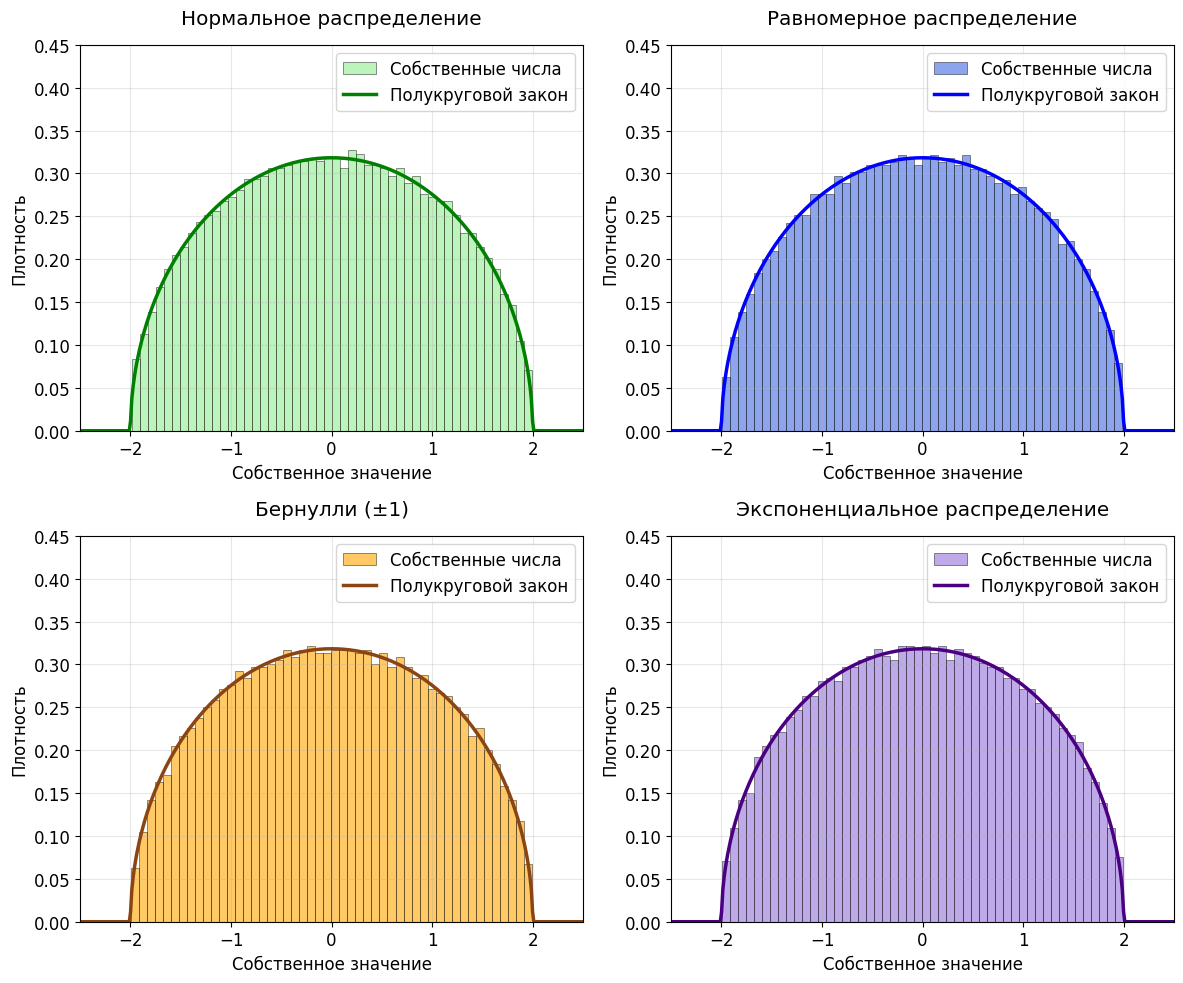

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

distributions = ['normal', 'uniform', 'bernoulli', 'exponential']
titles = ['Нормальное распределение', 'Равномерное распределение', 
          'Бернулли (±1)', 'Экспоненциальное распределение']
hist_colors = ['lightgreen', 'royalblue', 'orange', 'mediumpurple']
theory_colors = ['green', 'blue', 'saddlebrown', 'indigo']
line_styles = ['-', '-', '-', '-']

for idx, (ax, dist, title, hist_color, theory_color, line_style) in enumerate(
    zip(axes.flat, distributions, titles, hist_colors, theory_colors, line_styles)):
    
    evals = get_eigenvalues(dist)
    
    ax.hist(evals, bins=n_bins, density=True, alpha=0.6, 
            color=hist_color, edgecolor='black', linewidth=0.5,
            label='Собственные числа')
    
    x = np.linspace(-2.5, 2.5, 400)
    y = semicircle(x)
    ax.plot(x, y, color=theory_color, linestyle=line_style, 
            linewidth=2.5, label='Полукруговой закон')
    
    ax.set_title(title, pad=15)
    ax.set_xlabel('Собственное значение')
    ax.set_ylabel('Плотность')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 0.45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.tight_layout()
#plt.savefig('./pictures for diplom/test.png')
plt.show()